In [1]:
# conda activate chronocell

import os
import sys
import time
import pickle
import pandas as pd

os.chdir("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint")

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/janssens_2025_preprint/code")

import Chronocell
from reconstruct_RNA_history import *

from threadpoolctl import threadpool_limits
threadpool_limits(10)

In [ ]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [4]:
Y = traj.X
Q = traj.Q[:, 0, :] 
tau = traj.tau # State transition times (global)
t = traj.t
theta = traj.theta
topo = traj.topo
state_grid = np.searchsorted(tau, t, side="left") - 1
state_grid[0] = 0 

# Do this below with subset of genes

# theta_ = theta.copy()
# a0 = theta_[:, 0] # Starting RNA abundance 
# a = theta_[:, 1:len(topo.flatten())] 
# beta = theta_[:, -2] # Splicing rate
# alpha = a * beta[:, None] # These values are divided by splicing rate; removing this factor now
# gamma = theta_[:, -1] # Degradation rate

## Subset to genes with protein measurements

In [5]:
genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Order of genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist() # Genes to focus on

### What is the max # of counts for these genes?

In [6]:
mapped_mean_expr_U = Y[:, gene_idx, 0].max(axis=0)
mapped_mean_expr_S = Y[:, gene_idx, 1].max(axis=0)

In [7]:
np.sort(mapped_mean_expr_U)

array([  0.,   1.,   1.,   2.,   2.,   2.,   3.,   3.,   3.,   3.,   3.,
         3.,   3.,   3.,   4.,   4.,   4.,   4.,   5.,   6.,   6.,   6.,
         6.,   7.,   7.,   8.,   9.,  10.,  11.,  11.,  12.,  14.,  14.,
        16.,  16.,  16.,  19.,  19.,  22.,  22.,  24.,  25.,  27.,  27.,
        36.,  38.,  42.,  46.,  54.,  56.,  60., 115.])

In [8]:
np.sort(mapped_mean_expr_S)

array([  3.,   4.,   4.,   4.,   4.,   5.,   5.,   5.,   6.,   6.,   6.,
         7.,   7.,   7.,   7.,   7.,   7.,   8.,   8.,   8.,   8.,   8.,
         9.,  10.,  10.,  10.,  11.,  11.,  11.,  12.,  12.,  12.,  13.,
        13.,  14.,  16.,  16.,  16.,  18.,  18.,  20.,  21.,  25.,  27.,
        27.,  28.,  35.,  35.,  43.,  54.,  99., 105.])

In [ ]:
# Subset Chronocell data to genes of interest (with protein measurements)


Y = Y[:, gene_idx, :]
theta = theta[gene_idx, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

In [10]:
Y.shape

(21325, 52, 2)

In [11]:
# Gene names

gene_df = genes['Gene_symbol'][gene_idx]

In [12]:
gene_df

3         Cxcr4
9          Icos
12         Cd48
17        Cd24a
21         Cd63
24         Cd68
27         Ccr7
29      Cd300c2
33       Havcr2
48         Ighm
59         Irf4
63         Cd83
70       Lgals3
73         Il7r
82         Ly6e
88         Cd86
90        Cd200
93         Cd80
94         Btla
107       Ms4a1
109       Cd274
110         Fas
114      Entpd1
117        Dpp4
127       Itga4
129       Procr
135       Cd1d1
138       Vcam1
141      Notch2
150     Tnfrsf4
151    Tnfrsf18
152        Cd36
157        Flt3
158        Cd38
159         Kit
164       Cd207
167         Cd9
170       Klrk1
174        Cd8a
176     Clec12a
177      Clec9a
179        Pirb
182       Il4ra
183       Itgal
184       Itgax
186        Bst2
190       Lamp1
194       Itgb1
196        Fut4
201        Xcr1
203       Icam1
205        Jaml
Name: Gene_symbol, dtype: object

In [13]:
outdir = "data/RNA_history_per_gene"

## Reconstruct RNA

In [14]:
from threadpoolctl import threadpool_info
threadpool_info()

[{'user_api': 'blas',
  'internal_api': 'openblas',
  'num_threads': 10,
  'prefix': 'libopenblas',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libopenblasp-r0.3.29.so',
  'version': '0.3.29',
  'threading_layer': 'pthreads',
  'architecture': 'SkylakeX'},
 {'user_api': 'openmp',
  'internal_api': 'openmp',
  'num_threads': 10,
  'prefix': 'libgomp',
  'filepath': '/mnt/lareaulab/reliscu/anaconda3/envs/chronocell/lib/libgomp.so.1.0.0',
  'version': None}]

In [15]:
sparse_cutoff = 50

In [ ]:
X_fwd_per_gene = []
states_per_gene = []

n_genes = Y.shape[1]

for gene_idx in range(0, n_genes):
    # Set max # of RNAs based on observed values
    U_max, S_max = max_RNAs(Y, gene_idx)

    print("==================================")
    print(f"Starting gene {gene_idx + 1} out of {n_genes}")
    print("U_max, S_max:", U_max, S_max)
    
    gene_name = gene_df.iloc[gene_idx]
     
    states, index_for = enumerate_states(U_max, S_max)

    beta_j = beta[gene_idx]
    gamma_j = gamma[gene_idx] 
    alpha_j = alpha[gene_idx, :]
    Y_j = Y[:, gene_idx, :]

    # Make generator matrix (per transcription rate)
    A = []
    for i in range(0, alpha.shape[1]):
        rxns = define_reactions(alpha_j[i], beta_j, gamma_j)
        if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
            A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
        else:
            A1 = create_transition_matrix(rxns, states, index_for, U_max, S_max)
        A.append(A1)
    
    # Calculate forward probability distributions (needed for reverse generator)
    alpha0 = a0[gene_idx] * beta_j
    pi = stationary_from_params(alpha0, beta_j, gamma_j, states)
    start = time.perf_counter() 
    X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)
    end = time.perf_counter()
    print(f"Elapsed time for forward_distribution_blocked(): {end - start:.6f} seconds")
    
    # Calculate backward probability distributions
    
    start = time.perf_counter()
    if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
        X_bw = backward_distribution_sparse_to_dense(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution_sparse_to_dense(): {end - start:.6f} seconds")
    else:
        X_bw = backward_distribution(Y_j, Q, states, index_for, t, tau, state_grid)
        end = time.perf_counter()
        print(f"Elapsed time for backward_distribution(): {end - start:.6f} seconds")

    # Save highest probability state
    start = time.perf_counter()
    U_per_cell, S_per_cell = highest_prob_state_in_X_bw(X_bw, Q, states) 
    end = time.perf_counter()
    print(f"Elapsed time for highest_prob_state_in_X_bw(): {end - start:.6f} seconds")
         
    with open(f"{outdir}/{prefix}_{gene_name}_U_RNA_history.pkl", "wb") as f:
        pickle.dump(U_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    with open(f"{outdir}/{prefix}_{gene_name}_S_RNA_history.pkl", "wb") as f:
        pickle.dump(S_per_cell, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    X_fwd_per_gene.append(X_fwd)
    states_per_gene.append(states)
    
    get_expm.cache_clear()
    get_A_rev.cache_clear()
    get_expm_rev.cache_clear()
    get_A_rev_sparse_to_dense.cache_clear()
    get_expm_rev_sparse_to_dense.cache_clear()
    
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "wb") as f:
    pickle.dump(X_fwd_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)
    
with open(f"data/{prefix}_states_per_gene.pkl", "wb") as f:
    pickle.dump(states_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)

Starting gene 1 out of 52
U_max, S_max: 5 14
Elapsed time for forward_distribution_blocked(): 0.274195 seconds
Elapsed time for backward_distribution(): 1.991999 seconds
Elapsed time for highest_prob_state_in_X_bw(): 1.070959 seconds
Starting gene 2 out of 52
U_max, S_max: 16 9
Elapsed time for forward_distribution_blocked(): 0.155902 seconds
Elapsed time for backward_distribution(): 2.773377 seconds
Elapsed time for highest_prob_state_in_X_bw(): 2.725009 seconds
Starting gene 3 out of 52
U_max, S_max: 4 8
Elapsed time for forward_distribution_blocked(): 0.130258 seconds
Elapsed time for backward_distribution(): 0.582724 seconds
Elapsed time for highest_prob_state_in_X_bw(): 0.455654 seconds
Starting gene 4 out of 52
U_max, S_max: 4 18
Elapsed time for forward_distribution_blocked(): 0.111762 seconds
Elapsed time for backward_distribution(): 1.332330 seconds
Elapsed time for highest_prob_state_in_X_bw(): 1.102202 seconds
Starting gene 5 out of 52
U_max, S_max: 4 48
Elapsed time for for

In [ ]:
# # Just X_fwd

# X_fwd_per_gene = []
# states_per_gene = []

# n_genes = Y.shape[1]

# for gene_idx in range(0, n_genes):
#     # Set max # of RNAs based on observed values
#     U_max, S_max = max_RNAs(Y, gene_idx)

#     print("==================================")
#     print(f"Starting gene {gene_idx + 1} out of {n_genes}")
#     print("U_max, S_max:", U_max, S_max)
    
#     gene_name = gene_df.iloc[gene_idx]
     
#     states, index_for = enumerate_states(U_max, S_max)

#     beta_j = beta[gene_idx]
#     gamma_j = gamma[gene_idx] 
#     alpha_j = alpha[gene_idx, :]
#     Y_j = Y[:, gene_idx, :]

#     # Make generator matrix (per transcription rate)
#     A = []
#     for i in range(0, alpha.shape[1]):
#         rxns = define_reactions(alpha_j[i], beta_j, gamma_j)
#         if (U_max > sparse_cutoff) or (S_max > sparse_cutoff):
#             A1 = create_transition_matrix_sparse(rxns, states, index_for, U_max, S_max)
#         else:
#             A1 = create_transition_matrix(rxns, states, index_for, U_max, S_max)
#         A.append(A1)
    
#     # Calculate forward probability distributions (needed for reverse generator)
#     alpha0 = a0[gene_idx] * beta_j
#     pi = stationary_from_params(alpha0, beta_j, gamma_j, states)
#     start = time.perf_counter() 
#     X_fwd = forward_distribution_blocked(A, pi, states, t, tau, state_grid)
#     end = time.perf_counter()
#     print(f"Elapsed time for forward_distribution_blocked(): {end - start:.6f} seconds")
    
#     # Calculate backward probability distributions
    
#     X_fwd_per_gene.append(X_fwd)Z
#     states_per_gene.append(states)
    
#     get_expm.cache_clear()

# with open(f"data/{prefix}_X_fwd_per_gene.pkl", "wb") as f:
#     pickle.dump(X_fwd_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)
    
# with open(f"data/{prefix}_states_per_gene.pkl", "wb") as f:
#     pickle.dump(states_per_gene, f, protocol=pickle.HIGHEST_PROTOCOL)

Elapsed time for forward_distribution_blocked(): 0.504668 seconds
Starting gene 16 out of 52
U_max, S_max: 127 16
Elapsed time for forward_distribution_blocked(): 0.116503 seconds
Starting gene 17 out of 52
U_max, S_max: 18 13
Elapsed time for forward_distribution_blocked(): 0.136336 seconds
Starting gene 18 out of 52
U_max, S_max: 47 9
Elapsed time for forward_distribution_blocked(): 0.108353 seconds
Starting gene 19 out of 52
U_max, S_max: 28 5
Elapsed time for forward_distribution_blocked(): 0.066277 seconds
Starting gene 20 out of 52
U_max, S_max: 4 8
Elapsed time for forward_distribution_blocked(): 0.076912 seconds
Starting gene 21 out of 52
U_max, S_max: 42 13
Elapsed time for forward_distribution_blocked(): 2.406716 seconds
Starting gene 22 out of 52
U_max, S_max: 27 11
Elapsed time for forward_distribution_blocked(): 0.233293 seconds
Starting gene 23 out of 52
U_max, S_max: 40 5
Elapsed time for forward_distribution_blocked(): 0.077256 seconds
Starting gene 24 out of 52
U_max, 

## Compare reconstructed vs. simulated trajectories

In [ ]:
import glob
import pickle
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

from protein_from_RNA import *

In [74]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

# Get traj object from running Chronocell

with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

# Extract varies objects/parameters needed to simulate data

Y = traj.X
Q = traj.Q[:, 0, :] 
t = traj.t
theta = traj.theta
tau = traj.tau # State transition times (global)
topo = traj.topo 
# state_grid = np.searchsorted(tau, t, side="left") - 1
# state_grid[0] = 0 

# Subset data to genes of interest (with protein measurements)

genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Order of genes in Chronocell object
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
gene_idx = genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist() # Genes to focus on

Y = Y[:, gene_idx, :]
theta = theta[gene_idx, :]
theta_ = theta.copy()
a0 = theta_[:, 0] # Starting RNA abundance 
a = theta_[:, 1:len(topo.flatten())] 
beta = theta_[:, -2] # Splicing rate
alpha = a * beta[:, None] # Transcription rates are normalized by splicing rate; removing this factor now
gamma = theta_[:, -1] # Degradation rate

In [75]:
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)
    
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
    states_per_gene = pickle.load(f)

In [35]:
# Generate ground-truth simulated data

n = 2000 # No. cells
random_seed = 666

Y_observed, Y_sim, theta, rd, true_t, true_l = simulate_RNA(topo, tau, theta, n, random_seed=random_seed)

In [65]:
# Focus on one gene:

gene_idx = 4

In [ ]:
# Get forward trajectories
states = states_per_gene[gene_idx]
X_fwd = X_fwd_per_gene[gene_idx]
U_fwd, S_fwd = highest_prob_state_in_X_fwd(X_fwd, states)

# Load backward trajectories
gene_str = gene_df.iloc[gene_idx]
pattern = os.path.join(outdir, f"*_{gene_str}_S*")
file = glob.glob(pattern)[0]

with open(file, "rb") as f:
    X_bw_S = pickle.load(f)

Text(0, 0.5, '# molecules')

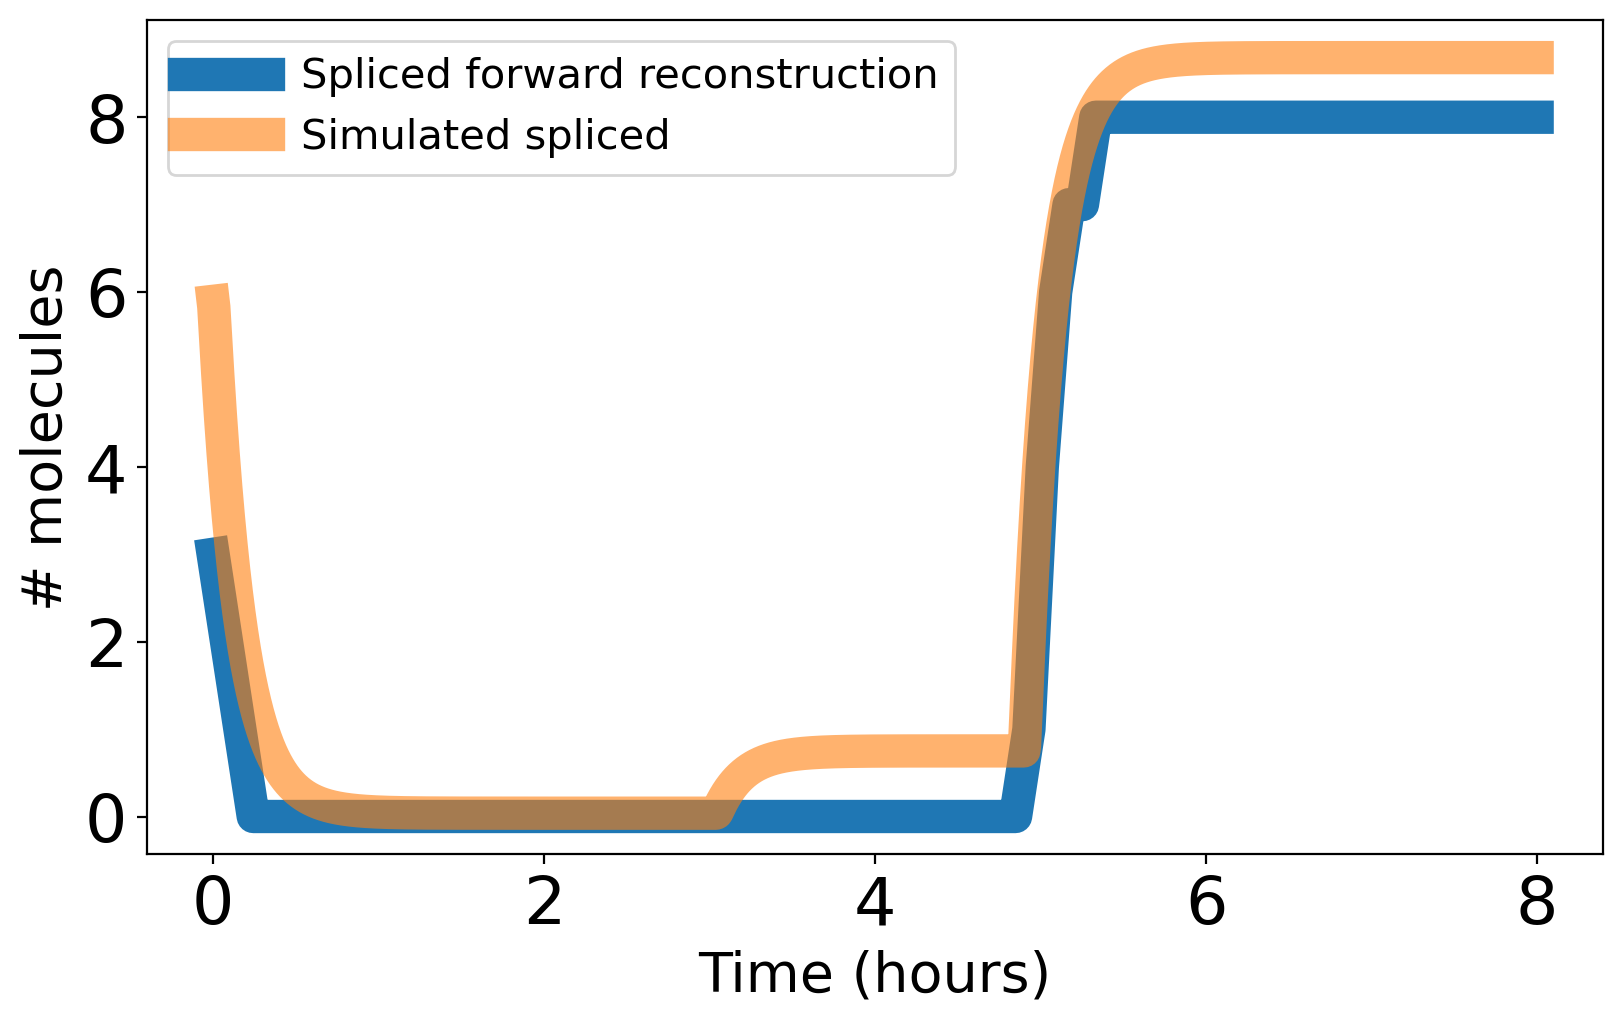

In [72]:
# First compare simulated vs. forward trajectory

# fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
# ax.plot(t, U_fwd, label="Unspliced forward reconstruction")
# ax.plot(true_t, Y_sim[:, gene_idx, 0], label="Simulated unspliced")
# ax.legend(fontsize=15)
# ax.set_xlabel("Time (hours)", fontsize=20)
# ax.set_ylabel("# molecules", fontsize=20)

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.plot(t, S_fwd, label="Spliced forward reconstruction")
ax.plot(true_t, Y_sim[:, gene_idx, 1], label="Simulated spliced", alpha=0.6)
ax.legend(fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)

Text(0, 0.5, '# molecules')

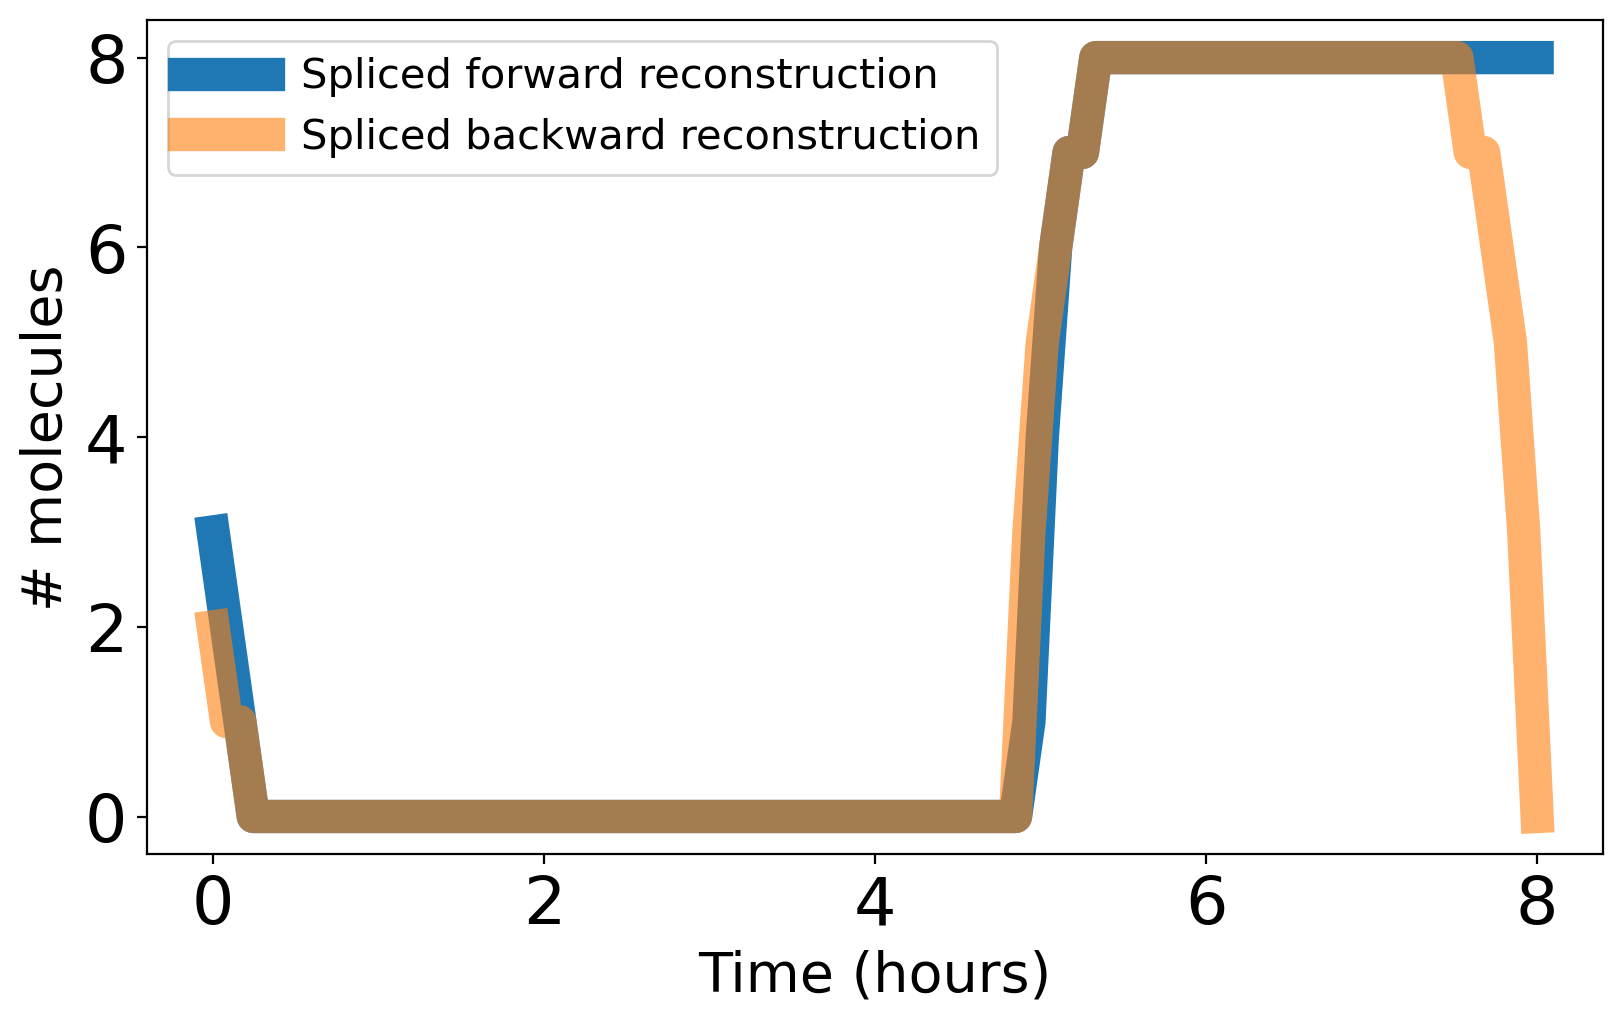

In [68]:
# Now compare forward vs. backward trajectory

# Pick cell at the end of trajectory:

t_obs = np.argmax(Q, axis=1)
cell_inds = np.where(t_obs == 99)[0]

i = 0

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.plot(t, S_fwd, label="Spliced forward reconstruction")
ax.plot(t, X_bw_S[cell_inds[i], :], label="Spliced backward reconstruction", alpha=0.6)
ax.legend(fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)

Text(0, 0.5, '# molecules')

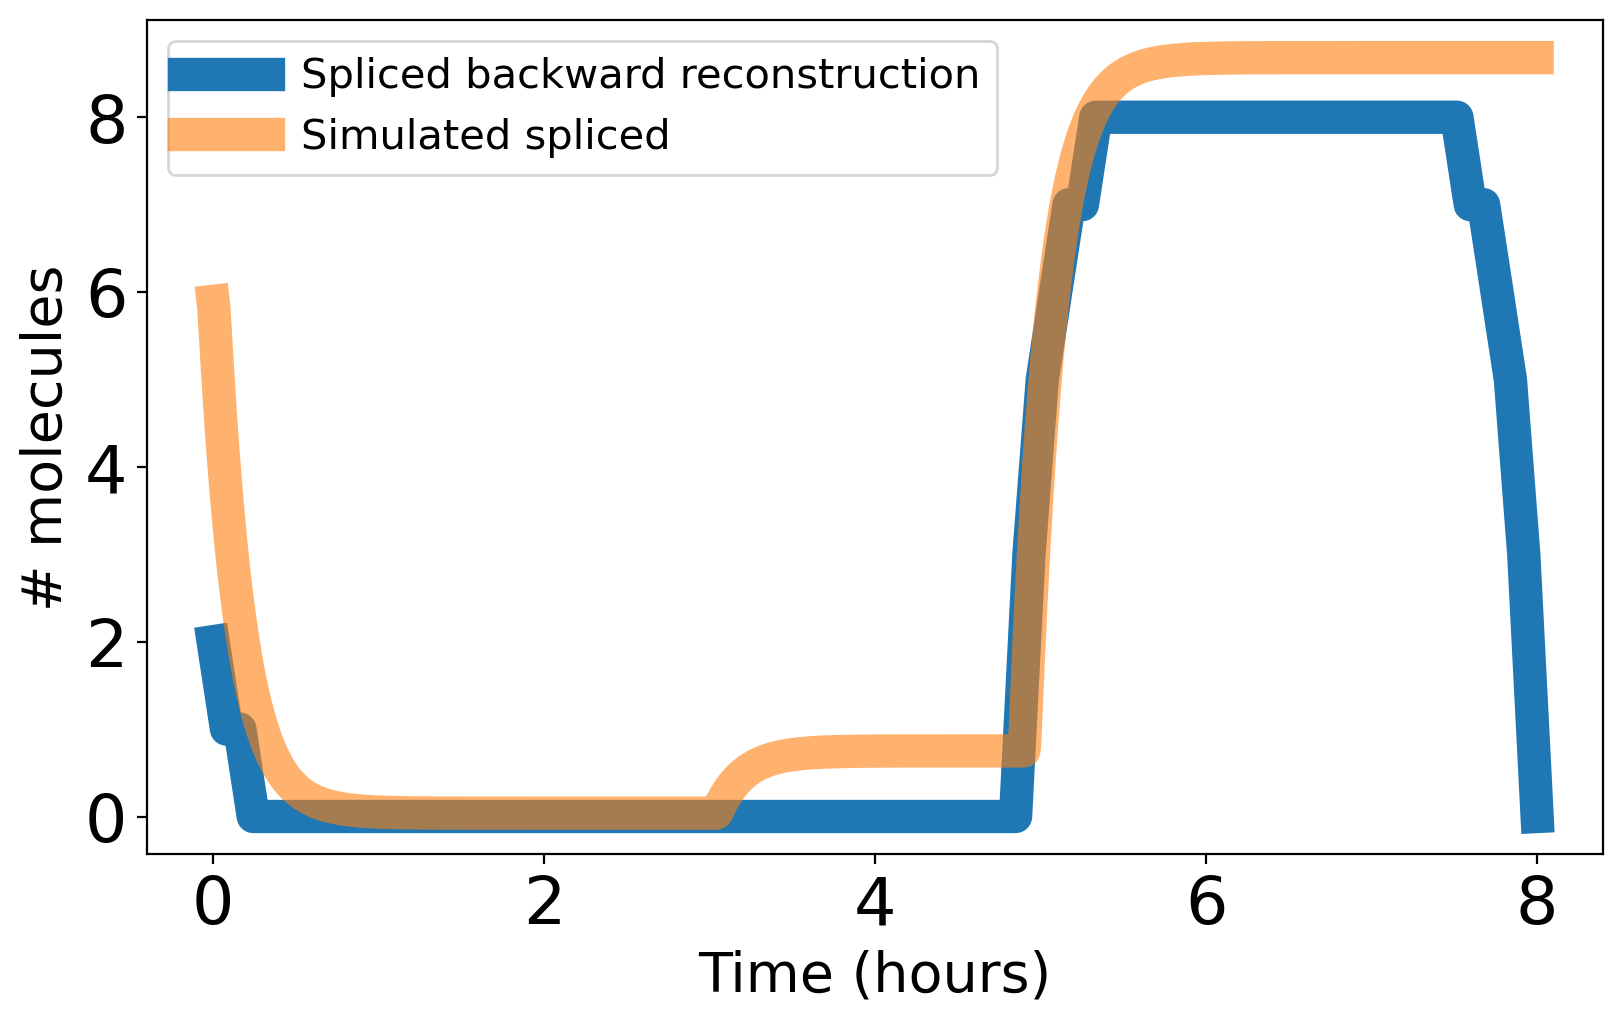

In [71]:
# Now compare simulated vs. backward trajectory

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)  # display dpi
ax.plot(t, X_bw_S[cell_inds[i], :], label="Spliced backward reconstruction")
ax.plot(true_t, Y_sim[:, gene_idx, 1], label="Simulated spliced", alpha=0.6)
ax.legend(fontsize=15)
ax.set_xlabel("Time (hours)", fontsize=20)
ax.set_ylabel("# molecules", fontsize=20)